# 03 — Rotation / Augmentation Debugging

Verify that **all** polygon parts — rooms *and* openings (`door`, `front_door`,
`window`) — follow the same rigid transform under the `__getitem__` augmentation
in `ResPlanDataset`.

The augmentation in [`dataset.py`](../src/floorplan_diffusion/data/dataset.py) is
applied to the whole `[MAX_NUM_POINTS, 2]` coordinate array in one operation, so
every part *should* move together. These cells confirm that visually and numerically.

Note on labels: the `rot=2` branch implements `(x,y) → (-y,-x)` (a reflection
across `y=-x`), inherited verbatim from upstream HouseDiffusion — not a true 180°
rotation. It is still a valid augmentation; the label below is kept for parity
with the source but flagged.

In [9]:
import sys, pickle
import random as _random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from floorplan_diffusion.data.dataset import (
    ResPlanDataset, MAX_NUM_POINTS, CORNER_IDX_DIMS, ROOM_IDX_DIMS,
    _normalize_keys, ROOM_TYPE_TO_INT,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"
%matplotlib inline

print("Ready.")

Ready.


In [10]:
# Map every type int the encoder can emit back to a name (incl. window=5).
ROOM_TYPE_INT_TO_NAME = {v: k for k, v in ROOM_TYPE_TO_INT.items()}

ROOM_COLORS = {
    "living":     "#E07B54",
    "bedroom":    "#F5C96A",
    "kitchen":    "#A8C5A0",
    "bathroom":   "#88B4D4",
    "balcony":    "#C9A8E0",
    "window":     "#3CB4C4",  # openings we specifically want to track
    "door":       "#888888",
    "front_door": "#444444",
}

OPENINGS = ("door", "front_door", "window")

def decode_plan(arr, cond):
    """Reconstruct per-part (corners, name) from an augmented (arr, cond) pair."""
    coords = arr.T.copy()
    real_mask = cond["src_key_padding_mask"] < 0.5
    room_type_oh = cond["room_types"]
    room_idx_oh  = cond["room_indices"]

    rooms = {}
    for i in np.where(real_mask)[0]:
        rtype_int = int(np.argmax(room_type_oh[i]))
        ridx      = int(np.argmax(room_idx_oh[i]))
        rooms.setdefault((ridx, rtype_int), []).append(coords[i])

    return [(np.array(pts), ROOM_TYPE_INT_TO_NAME.get(rtype_int, str(rtype_int)))
            for (ridx, rtype_int), pts in sorted(rooms.items())]


def render_decoded(rooms, title, ax):
    ax.set_title(title, fontsize=9)
    ax.set_aspect("equal")
    ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
    ax.axhline(0, color="#ccc", lw=0.5); ax.axvline(0, color="#ccc", lw=0.5)
    for pts, name in rooms:
        color = ROOM_COLORS.get(name, "#cccccc")
        if len(pts) >= 3:
            ax.add_patch(plt.Polygon(pts, closed=True, fc=color, ec="black",
                                     alpha=0.6, lw=0.8, label=name))
        ax.scatter(pts[:, 0], pts[:, 1], s=12, c="black", zorder=3)
        # Mark opening centroids so they are easy to follow across rotations.
        if name in OPENINGS:
            cx, cy = pts.mean(axis=0)
            marker_color = {"front_door": "red", "door": "orange", "window": "blue"}[name]
            ax.plot(cx, cy, "x", ms=8, mew=2, color=marker_color, zorder=4)

print("Helpers ready.")

Helpers ready.


In [ ]:
PKL_PATH = PROJECT_ROOT / "data" / "raw" / "ResPlan.pkl"

# Load raw plan dicts only — building the full ResPlanDataset materialises a
# 192x192x3 float64 mask stack per plan (~85 MB/plan) and OOMs. We only need one.
with open(PKL_PATH, "rb") as f:
    raw_plans = pickle.load(f)

WINDOW_TYPE_INT     = ROOM_TYPE_TO_INT["window"]      # 5
DOOR_TYPE_INT       = ROOM_TYPE_TO_INT["door"]        # 11
FRONT_DOOR_TYPE_INT = ROOM_TYPE_TO_INT["front_door"]  # 13

# A bare instance so we can call _process_plan without the heavy __init__.
ds = ResPlanDataset.__new__(ResPlanDataset)
ds.set_name = "train"          # augmentation active
ds.num_coords = 2
ds.max_num_points = MAX_NUM_POINTS

RT_END = 2 + 25
PAD_COL = RT_END + CORNER_IDX_DIMS + ROOM_IDX_DIMS

def encoded_type_ints(house_array):
    """Set of room-type ints present among the real (non-padded) points."""
    real = house_array[:, PAD_COL] > 0.5
    return set(np.argmax(house_array[real, 2:RT_END], axis=1).tolist())

# Pick the first plan that survives _process_plan AND contains all three opening
# types, so the visualization can actually track windows + both door kinds.
target_plan, result = None, None
WANT = {WINDOW_TYPE_INT, DOOR_TYPE_INT, FRONT_DOOR_TYPE_INT}
for p in raw_plans:
    r = ds._process_plan(p)
    if r is not None and WANT <= encoded_type_ints(r[0]):
        target_plan, result = p, r
        break

assert result is not None, "No plan with window+door+front_door survived processing."

house_array, d_mask, s_mask, g_mask = result
ds.houses     = [house_array]
ds.door_masks = [d_mask]
ds.self_masks = [s_mask]
ds.gen_masks  = [g_mask]
target_idx = 0

print(f"Using plan id={target_plan.get('id', '?')}  "
      f"type ints present: {sorted(encoded_type_ints(house_array))}")
print("Single-plan dataset ready.")

Using plan id=14433  type ints present: [1, 2, 3, 4, 5, 10, 11, 13]
Single-plan dataset ready.


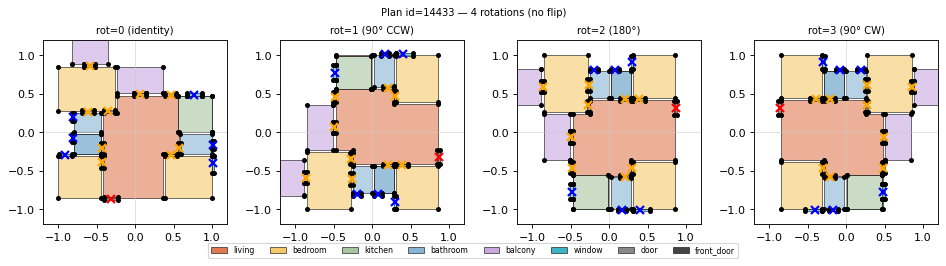

Saved to rotation_check.png


In [12]:
ROTATION_LABELS = {
    0: "rot=0 (identity)",
    1: "rot=1 (90° CCW)",
    2: "rot=2 (180°)",
    3: "rot=3 (90° CW)",
}

fig, axes = plt.subplots(1, 4, figsize=(12, 3), dpi=80)
fig.suptitle(f"Plan id={target_plan.get('id','?')} — 4 rotations (no flip)", fontsize=9)

for rot in range(4):
    orig_randint = _random.randint
    orig_random  = _random.random
    _random.randint = lambda a, b, r=rot: r
    _random.random  = lambda: 1.0

    arr, cond = ds[0]

    _random.randint = orig_randint
    _random.random  = orig_random

    render_decoded(decode_plan(arr, cond), ROTATION_LABELS[rot], axes[rot])

handles = [plt.Rectangle((0,0),1,1, fc=c, ec="k", lw=0.5) for c in ROOM_COLORS.values()]
fig.legend(handles, list(ROOM_COLORS.keys()), loc="lower center",
           ncol=len(ROOM_COLORS), fontsize=7, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.savefig("rotation_check.png", dpi=80, bbox_inches="tight")
plt.show()
print("Saved to rotation_check.png")


In [5]:
# Numerical check: every part (rooms AND openings) must obey the SAME transform.
# We compute each rotation's expected coords directly from rot=0 and compare,
# matching parts by (room_idx, type) so rooms and openings are checked alike.

def decode_indexed(arr, cond):
    """Like decode_plan but keyed by (room_idx, type_int) for stable matching."""
    coords = arr.T
    real = cond["src_key_padding_mask"] < 0.5
    rt, ri = cond["room_types"], cond["room_indices"]
    out = {}
    for i in np.where(real)[0]:
        key = (int(np.argmax(ri[i])), int(np.argmax(rt[i])))
        out.setdefault(key, []).append(coords[i])
    return {k: np.array(v) for k, v in out.items()}

def forced_getitem(rot):
    o_ri, o_r = _random.randint, _random.random
    _random.randint = lambda a, b: rot   # force rotation branch
    _random.random  = lambda: 1.0        # 1.0 < 0.5 is False -> no flips
    try:
        return ds[target_idx]
    finally:
        _random.randint, _random.random = o_ri, o_r

# Expected coordinate transforms applied to rot=0 points (x,y):
ROT_FN = {
    0: lambda p: p,
    1: lambda p: np.stack([-p[:, 1],  p[:, 0]], axis=1),  # (x,y)->(-y, x)
    2: lambda p: np.stack([-p[:, 1], -p[:, 0]], axis=1),  # (x,y)->(-y,-x)  upstream "180"
    3: lambda p: np.stack([ p[:, 1], -p[:, 0]], axis=1),  # (x,y)->( y,-x)
}

base = decode_indexed(*forced_getitem(0))

print(f"{'rot':<4}{'part (idx,type)':<24}{'max |err|':>12}  status")
print("-" * 50)
all_ok = True
for rot in range(4):
    parts = decode_indexed(*forced_getitem(rot))
    for key, pts in sorted(parts.items()):
        ridx, tint = key
        name = ROOM_TYPE_INT_TO_NAME.get(tint, str(tint))
        expected = ROT_FN[rot](base[key])
        err = np.abs(pts - expected).max()
        ok = err < 1e-9
        all_ok &= ok
        tag = "OPENING" if name in OPENINGS else "room"
        print(f"{rot:<4}{f'({ridx},{name})':<24}{err:>12.2e}  "
              f"{'OK' if ok else 'MISMATCH'}  [{tag}]")
    print()

print("ALL PARTS (rooms + openings) follow the augmentation transform:" ,
      "YES" if all_ok else "NO")

rot part (idx,type)            max |err|  status
--------------------------------------------------
0   (1,living)                  0.00e+00  OK  [room]
0   (2,bedroom)                 0.00e+00  OK  [room]
0   (3,bedroom)                 0.00e+00  OK  [room]
0   (4,bedroom)                 0.00e+00  OK  [room]
0   (5,kitchen)                 0.00e+00  OK  [room]
0   (6,window)                  0.00e+00  OK  [OPENING]
0   (7,window)                  0.00e+00  OK  [OPENING]
0   (8,window)                  0.00e+00  OK  [OPENING]
0   (9,window)                  0.00e+00  OK  [OPENING]
0   (10,window)                 0.00e+00  OK  [OPENING]
0   (11,window)                 0.00e+00  OK  [OPENING]
0   (12,bathroom)               0.00e+00  OK  [room]
0   (13,bathroom)               0.00e+00  OK  [room]
0   (14,bathroom)               0.00e+00  OK  [room]
0   (15,bathroom)               0.00e+00  OK  [room]
0   (16,balcony)                0.00e+00  OK  [room]
0   (17,balcony)                0.

## ResPlan-style rendering of sample tensors

Port of HouseDiffusion's `save_samples` ([`scripts/image_sample.py`](../external/house_diffusion/scripts/image_sample.py))
into the **ResPlan `plot_plan` look** ([`resplan_utils.plot_plan`](../external/ResPlan/resplan_utils.py)):
solid `CATEGORY_COLORS` fills, thin black edges, equal aspect, no axis, plus the
synthesized wall lattice.

The point-walking / room-splitting that `save_samples` does (start a new polygon
whenever `room_indices` changes) is already factored into the package as
`points_to_room_polygons`; the matplotlib styling mirrors `render_floorplan` in
[`scripts/sample.py`](../scripts/sample.py). It works on **any** `(arr, cond)`
pair — a ground-truth dataset item *or* a model sample tensor of shape
`[2, MAX_NUM_POINTS]`.

In [13]:
from matplotlib.patches import PathPatch
from matplotlib.path import Path as MplPath

from floorplan_diffusion.evaluation.render import (
    CATEGORY_COLORS, CATEGORY_ORDER, derive_walls, points_to_room_polygons,
)

INT_TO_ROOM_NAME = {v: k for k, v in ROOM_TYPE_TO_INT.items()}
DOOR_INTS = frozenset({ROOM_TYPE_TO_INT["door"], ROOM_TYPE_TO_INT["front_door"]})


def _shapely_to_pathpatch(geom, **kwargs):
    """Shapely (Multi)Polygon with holes -> matplotlib PathPatch (even-odd fill)."""
    from shapely.geometry import Polygon as _Polygon
    polys = list(geom.geoms) if hasattr(geom, "geoms") else [geom]
    vertices, codes = [], []
    for poly in polys:
        if not isinstance(poly, _Polygon) or poly.is_empty:
            continue
        for ring in (poly.exterior, *poly.interiors):
            rc = np.asarray(ring.coords)
            if len(rc) < 3:
                continue
            vertices.append(rc)
            codes.append(MplPath.MOVETO)
            codes.extend([MplPath.LINETO] * (len(rc) - 1))
    if not vertices:
        return None
    return PathPatch(MplPath(np.concatenate(vertices), codes), **kwargs)


def render_floorplan(room_polygons, title="", ax=None, draw_walls=True,
                     wall_thickness=0.025):
    """Render `points_to_room_polygons` output in the ResPlan `plot_plan` style.

    Mirrors `render_floorplan` in scripts/sample.py: solid CATEGORY_COLORS fills,
    thin black edges, equal aspect, no axis, with a synthesized yellow wall
    lattice layered between room fills and doors.
    """
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(6, 6))

    order = {name: i for i, name in enumerate(CATEGORY_ORDER)}
    ordered = sorted(room_polygons,
                     key=lambda r: order.get(INT_TO_ROOM_NAME.get(r[1], ""), len(order)))

    def _draw(coords, rtype):
        name = INT_TO_ROOM_NAME.get(rtype, f"type_{rtype}")
        ax.add_patch(plt.Polygon(coords, closed=True,
                                 facecolor=CATEGORY_COLORS.get(name, "#000000"),
                                 edgecolor="black", linewidth=0.5,
                                 label=name.replace("_", " ")))

    # 1. Room fills (doors deferred so they sit on top of walls).
    for coords, rtype in ordered:
        if len(coords) >= 3 and rtype not in DOOR_INTS:
            _draw(coords, rtype)

    # 2. Synthesized walls (same derivation for GT and generated).
    if draw_walls:
        walls = derive_walls(room_polygons, wall_thickness=wall_thickness)
        if walls is not None:
            patch = _shapely_to_pathpatch(walls, facecolor=CATEGORY_COLORS["wall"],
                                          edgecolor="black", linewidth=0.3, label="wall")
            if patch is not None:
                ax.add_patch(patch)

    # 3. Doors on top of walls.
    for coords, rtype in ordered:
        if len(coords) >= 3 and rtype in DOOR_INTS:
            _draw(coords, rtype)

    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()                     # match plot_plan's image-coordinate look
    ax.set_title(title)
    ax.set_axis_off()
    return ax


def render_sample(arr, cond, title="", ax=None, draw_walls=True):
    """Convenience: (arr[2,N], cond) -> ResPlan-style plot. Works for GT or model output."""
    points = np.asarray(arr).T                       # [N, 2]
    polys = points_to_room_polygons(
        points, cond["room_types"], cond["room_indices"], cond["src_key_padding_mask"])
    return render_floorplan(polys, title=title, ax=ax, draw_walls=draw_walls)


print("ResPlan-style render helpers ready.")

ResPlan-style render helpers ready.


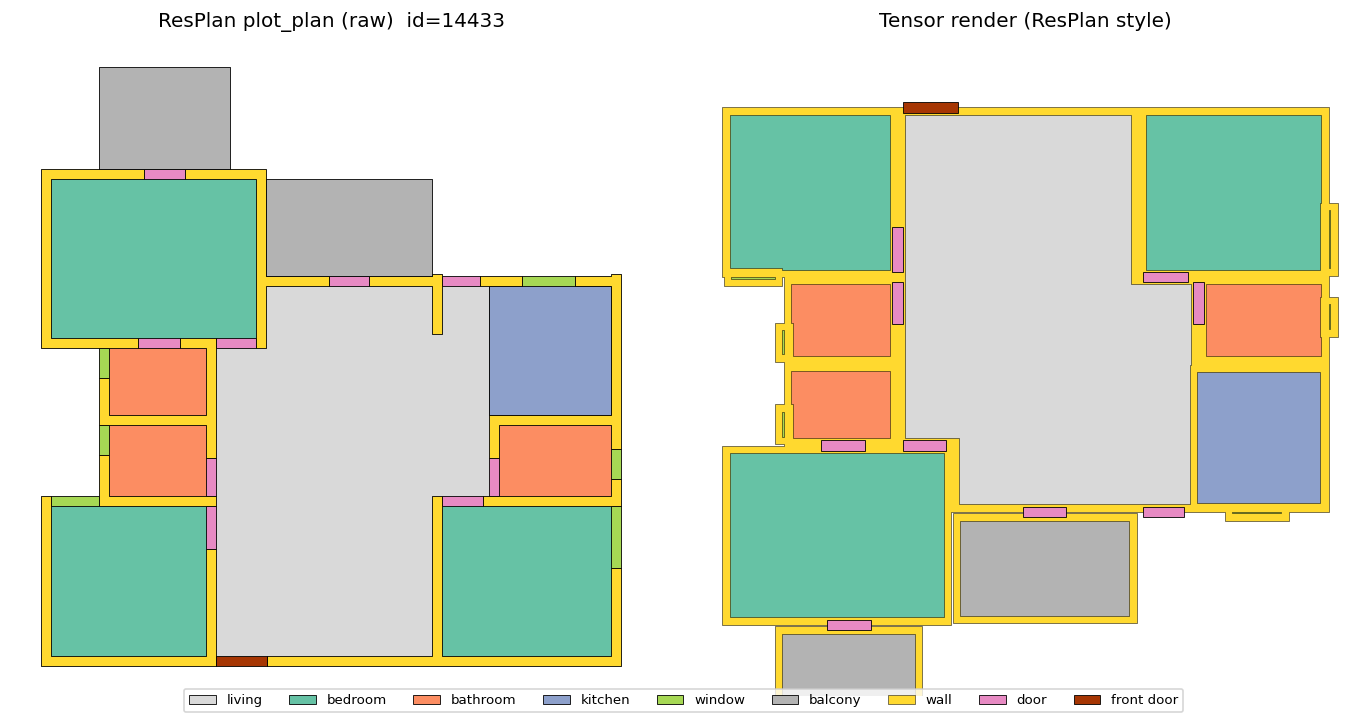

Saved to sample_render_check.png


In [14]:
# Side-by-side: raw ResPlan plot_plan  vs  our tensor render (same plan, no aug).
sys.path.insert(0, str(PROJECT_ROOT / "external" / "ResPlan"))
from resplan_utils import plot_plan

# Identity item (force rot=0, no flips) so geometry matches the raw plan.
arr0, cond0 = forced_getitem(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_plan(dict(target_plan), ax=axes[0], legend=False,
          title=f"ResPlan plot_plan (raw)  id={target_plan.get('id','?')}")
render_sample(arr0, cond0, title="Tensor render (ResPlan style)", ax=axes[1])

# De-duplicated legend from the right panel.
handles, labels = axes[1].get_legend_handles_labels()
seen, uniq = set(), []
for h, lab in zip(handles, labels):
    if lab not in seen:
        seen.add(lab); uniq.append((h, lab))
if uniq:
    fig.legend(*zip(*uniq), loc="lower center", ncol=len(uniq), fontsize=8)

fig.tight_layout()
plt.savefig("sample_render_check.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved to sample_render_check.png")

## Discussion: how should walls treat windows?

`evaluation.render.derive_walls` currently buffers the boundary of **every
non-door polygon** into a wall band, unions them, and the room interiors stay as
holes. It only skips door types `{11, 13}` — **windows (type 5) are walled like
rooms**, so each window outline gets traced in yellow (the boxed-in look in the
panel above).

Architecturally a window is an *opening in a wall*, like a door — the original
HouseDiffusion groups `door_indices = [11, 12, 13]` and never walls them. Three
options to weigh:

| Option | What it does | Trade-off |
|---|---|---|
| **A — current** | window is walled like a room | wrong: windows boxed in |
| **B — skip** | exclude window from wall bands (treat like a door) | simple; window still floats as a lime fill, walls ignore it |
| **C — skip + cut** | skip window bands *and* subtract window footprints from the wall lattice | windows punch real gaps in walls; placement noise can leave small artifacts |

The cell below renders A / B / C side by side **without modifying the package**,
using a local copy of `derive_walls` with a configurable skip set + cut flag.

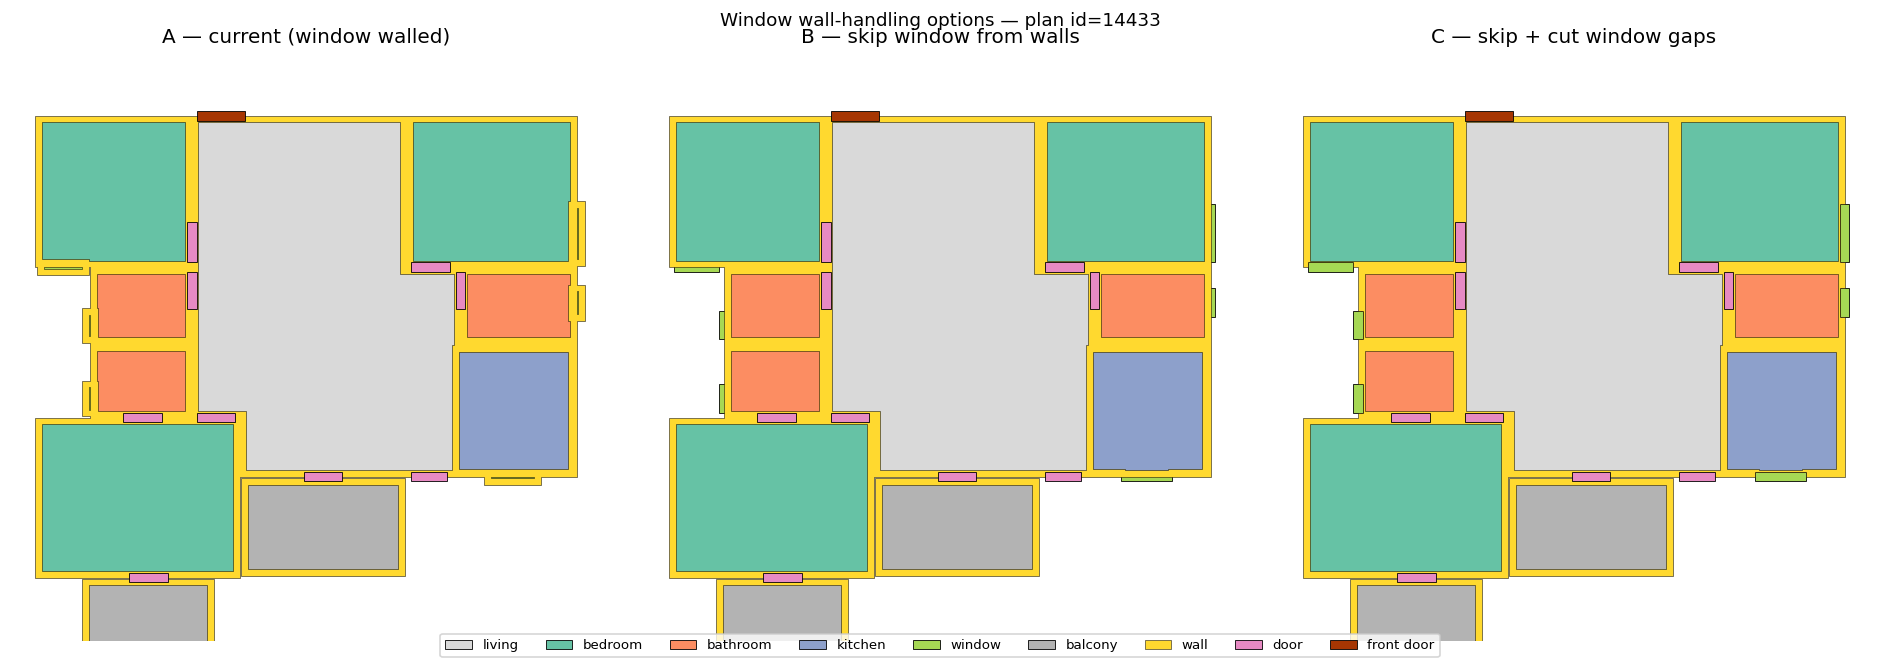

Saved to window_wall_options.png


In [15]:
# Local, package-untouched variant of derive_walls with configurable handling.
from shapely.geometry import Polygon as _Polygon
from shapely.ops import unary_union
from floorplan_diffusion.evaluation.render import _is_degenerate

WINDOW_INT = ROOM_TYPE_TO_INT["window"]   # 5

def derive_walls_variant(room_polygons, wall_thickness=0.025,
                         skip_types=frozenset({11, 13}), cut_windows=False):
    """Like evaluation.render.derive_walls, but:
      - skip_types: polygon types that get NO wall band (doors always; +window for B/C).
      - cut_windows: if True, subtract window footprints from the merged lattice (C).
    """
    half = wall_thickness / 2.0
    bands, window_polys = [], []
    for coords, rtype in room_polygons:
        if _is_degenerate(coords):
            continue
        poly = _Polygon(coords)
        if not poly.is_valid:
            poly = poly.buffer(0)
        if poly.is_empty:
            continue
        if rtype == WINDOW_INT:
            window_polys.append(poly)            # remember for optional cutting
        if rtype in skip_types:
            continue
        band = poly.boundary.buffer(half, cap_style=2, join_style=2)
        if not band.is_empty:
            bands.append(band)

    if not bands:
        return None
    merged = unary_union(bands)
    if cut_windows and window_polys:
        merged = merged.difference(unary_union(window_polys))
    return merged if not merged.is_empty else None


def render_variant(room_polygons, title, ax, skip_types, cut_windows):
    """Same layering as render_floorplan but with a pluggable wall derivation."""
    order = {name: i for i, name in enumerate(CATEGORY_ORDER)}
    ordered = sorted(room_polygons,
                     key=lambda r: order.get(INT_TO_ROOM_NAME.get(r[1], ""), len(order)))

    def _draw(coords, rtype):
        name = INT_TO_ROOM_NAME.get(rtype, f"type_{rtype}")
        ax.add_patch(plt.Polygon(coords, closed=True,
                                 facecolor=CATEGORY_COLORS.get(name, "#000000"),
                                 edgecolor="black", linewidth=0.5, label=name.replace("_", " ")))

    for coords, rtype in ordered:                      # room fills
        if len(coords) >= 3 and rtype not in DOOR_INTS:
            _draw(coords, rtype)
    walls = derive_walls_variant(room_polygons, skip_types=skip_types, cut_windows=cut_windows)
    if walls is not None:                              # wall lattice
        patch = _shapely_to_pathpatch(walls, facecolor=CATEGORY_COLORS["wall"],
                                      edgecolor="black", linewidth=0.3, label="wall")
        if patch is not None:
            ax.add_patch(patch)
    for coords, rtype in ordered:                      # doors on top
        if len(coords) >= 3 and rtype in DOOR_INTS:
            _draw(coords, rtype)
    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal", adjustable="box"); ax.invert_yaxis()
    ax.set_title(title); ax.set_axis_off()


# Build polygons once from the identity (rot=0) item, then render A / B / C.
arr0, cond0 = forced_getitem(0)
polys = points_to_room_polygons(arr0.T, cond0["room_types"],
                                cond0["room_indices"], cond0["src_key_padding_mask"])

VARIANTS = [
    ("A — current (window walled)", frozenset({11, 13}),    False),
    ("B — skip window from walls",  frozenset({5, 11, 13}), False),
    ("C — skip + cut window gaps",  frozenset({5, 11, 13}), True),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, (title, skip, cut) in zip(axes, VARIANTS):
    render_variant(polys, title, ax, skip_types=skip, cut_windows=cut)

handles, labels = axes[0].get_legend_handles_labels()
seen, uniq = set(), []
for h, lab in zip(handles, labels):
    if lab not in seen:
        seen.add(lab); uniq.append((h, lab))
if uniq:
    fig.legend(*zip(*uniq), loc="lower center", ncol=len(uniq), fontsize=8)
fig.suptitle(f"Window wall-handling options — plan id={target_plan.get('id','?')}", fontsize=11)
fig.tight_layout()
plt.savefig("window_wall_options.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved to window_wall_options.png")